<h1><center> Gravity Reductions: A Tutorial </center></h1>

## 1. Theory

This Notebook demonstrates **gravity reductions**, the process of reducing gravity measured at the Earth's surface ($g$) down to the geoid ($g_0$). We **synthesize** gravity at arbitrary points from a Global Geopotential Model (GGM) and **extract** elevations from a Digital Elevation Model (DEM). 

This is purely for demonstration purposes! Do NOT use this data for actual research unless your research specifically deals with synthesized data.

### 1.1 Free-air reduction

The free-air reduction accounts for the change in gravity with height. To first order, the vertical gravity gradient is $\partial g / \partial H \approx -0.3086$ mGal/m, so:

$$
g_F = g + F, \qquad F = 0.3086 \, H
$$

where $H$ is the orthometric height (elevation above the geoid) in metres and $g_F$ is the free-air reduced gravity at the geoid, in mGal.

### 1.2 Bouguer reduction

The Bouguer (or simple Bouguer) reduction removes the gravitational attraction of the topographic mass between the point and the geoid. The mass is approximated by an infinite horizontal slab, the *Bouguer plate*, whose attraction is:

$$
A_B = 2 \pi G \rho H
$$

With $G = 6.67430 \times 10^{-11}$ m $^3$ kg $^{-1}$ s $^{-2}$ and standard crustal density $\rho = 2670$ kg m $^{-3}$, this evaluates to $A_B \approx 0.1119 \, H$ mGal. The Bouguer-reduced gravity at the geoid is therefore:

$$
g_B = g - A_B + F = g - 0.1119\,H + 0.3086\,H
$$

### 1.3 From reduced gravity to anomalies

Once gravity has been reduced to the geoid, the gravity anomaly is the difference between the reduced gravity and normal gravity ($\gamma_0$) on the reference ellipsoid:

$$
\Delta g_x = g_x - \gamma_0
$$

where the subscript $x$ is $F$ for the free-air anomaly or $B$ for the Bouguer anomaly.

### 1.4 Workflow overview

1. **Define** a set of computation points (lon, lat) over a region of interest.
2. **Extract** elevations $H$ at those points from a DEM.
3. **Synthesise** gravity $g$ at the surface points from a GGM.
4. **Apply** free-air and Bouguer reductions.
5. **Compute** normal gravity $\gamma_0$ on the ellipsoid (Somigliana's formula).
6. **Obtain** the free-air and Bouguer anomalies.
7. **Plot** the results.

We start by importing the relevant modules. The magic commands `%load_ext autoreload` and `%autoreload 2` enable automatic reloading of modified modules during development.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from geoidlab import gravity as pygrav
from geoidlab.ggm import GlobalGeopotentialModel
from geoidlab.dem import dem4geoid
from geoidlab.plot import plot_gravity_anomaly

## 2. Define computation points

We create a regular grid of points over southern Ghana. A moderate grid spacing (~0.1 $^\circ$) keeps the GGM synthesis fast while providing enough detail for visualisation.

In [33]:
# Define bounding box and grid spacing
lon_min, lon_max = -3.5, 1.5
lat_min, lat_max = 6, 11.5
spacing = 0.1  # degrees

# Build regular grid
lon_vals = np.arange(lon_min, lon_max + spacing, spacing)
lat_vals = np.arange(lat_min, lat_max + spacing, spacing)
Lon, Lat = np.meshgrid(lon_vals, lat_vals)

# Flatten to 1-D arrays for pointwise processing
lon_flat = Lon.ravel()
lat_flat = Lat.ravel()

print(f'{len(lon_flat)} computation points  ({len(lon_vals)} lon \u00d7 {len(lat_vals)} lat)')

2856 computation points  (51 lon × 56 lat)


## 3. Extract elevations from a DEM

We use `dem4geoid` to fetch SRTM30+ elevations at every computation point. The function downloads and caches the DEM tiles automatically.

In [34]:
bbox = [lon_min, lon_max, lat_min, lat_max]

# Download and subset DEM
dem = dem4geoid(
    bbox=bbox,
    model='srtm30plus',
    resolution=30,           # arc-seconds
    interp_method='slinear',
    downloads_dir='downloads'
)

# Interpolate DEM heights to our computation points
import xarray as xr
H = dem['z'].interp(
    x=xr.DataArray(lon_flat, dims='points'),
    y=xr.DataArray(lat_flat, dims='points'),
    method='linear'
).values

print(f'Elevation range: {H.min():.1f} to {H.max():.1f} m')

w020n40.nc exists and covers bbox. Using local copy.

Creating xarray dataset of DEM with buffer of 1 degree(s)

Aligning DEM to bounding box and resampling DEM to 30 arc-seconds...
DEM alignment and resampling completed in 0.20 seconds.

Elevation range: -152.2 to 806.7 m


## 4. Synthesise surface gravity from a GGM

We use the **GO_CONS_GCF_2_TIM_R6e** model (already downloaded) to compute the **gravity disturbance** $\delta g$ at each point. The gravity disturbance is the difference between actual gravity and normal gravity at the *same point* on the Earth\u2019s surface:

$$
\delta g = g(P) - \gamma(P)
$$

We recover surface gravity as $g(P) = \gamma(h) + \delta g$, where $\gamma(h)$ is the normal gravity computed at the height $h$ of the point.

In [35]:
# Build DataFrame for GGM input
grav_data = pd.DataFrame({
    'lon': lon_flat,
    'lat': lat_flat,
    'height': H
})

# Initialise GGM and compute gravity disturbance at surface
ggm = GlobalGeopotentialModel(
    model_name='GO_CONS_GCF_2_TIM_R6e',
    grav_data=grav_data,
    nmax=300,
    ellipsoid='grs80',
    model_dir='downloads',
    chunk_size=500
)

# Gravity disturbance \u03b4g at surface height (mGal)
dg = ggm.gravity_disturbance()

# Normal gravity above ellipsoid at point height (mGal)
gamma_h = pygrav.normal_gravity_above_ellipsoid(
    phi=lat_flat, h=H, ellipsoid='grs80'
)

# Surface gravity g(P) = \u03b3(h) + \u03b4g
g_surface = gamma_h + dg

print(f'Surface gravity range: {g_surface.min():.2f} to {g_surface.max():.2f} mGal')

Large array detected (2856 points). Processing in batches of 1000 to avoid memory issues...
Forcing parallel=False for large arrays to prevent memory issues. Pass force_parallel=True to override this safeguard.
Processing batch 1/3 (points 1-1000)...


Computing gravity disturbance: 100%|██████████| 299/299 [00:00<00:00, 800.28it/s] 


Processing batch 2/3 (points 1001-2000)...


Computing gravity disturbance: 100%|██████████| 299/299 [00:00<00:00, 791.31it/s] 


Processing batch 3/3 (points 2001-2856)...


Computing gravity disturbance: 100%|██████████| 299/299 [00:00<00:00, 846.04it/s] 

Completed processing all 3 batches.
Surface gravity range: 977892.91 to 978192.13 mGal


## 5. Apply gravity reductions

With surface gravity $g$ and elevation $H$ in hand, we apply the free-air and Bouguer reductions. `geoidlab` provides `gravity_reduction()` for this:

In [36]:
g_free, g_bouguer = pygrav.gravity_reduction(
    gravity=g_surface,
    elevation=H
)

print('Free-air and Bouguer gravity reductions computed.')

Free-air and Bouguer gravity reductions computed.


### Manual reduction (for transparency)

The same result can be obtained by hand, which makes the underlying arithmetic explicit:

In [37]:
# Free-air reduction
g_free_manual = g_surface + 0.3086 * H

# Bouguer reduction
g_bouguer_manual = g_free_manual - 0.1119 * H

# Verify against library function
assert np.allclose(g_free, g_free_manual, atol=1e-10)
assert np.allclose(g_bouguer, g_bouguer_manual, atol=1e-10)
print('Manual reductions match geoidlab.gravity_reduction() \u2713')

Manual reductions match geoidlab.gravity_reduction() ✓


## 6. Compute normal gravity and gravity anomalies

Normal gravity $\gamma_0$ on the ellipsoid is given by Somigliana\u2019s formula. The anomaly is the difference between the reduced gravity (at the geoid) and $\gamma_0$:

In [38]:
# Normal gravity on ellipsoid (m/s² → mGal)
gamma0 = pygrav.normal_gravity_somigliana(phi=lat_flat, ellipsoid='grs80') * 1e5

# Anomalies
free_air_anomaly = g_free - gamma0
bouguer_anomaly  = g_bouguer - gamma0

print(f'Free-air anomaly range:  {free_air_anomaly.min():.1f} to {free_air_anomaly.max():.1f} mGal')
print(f'Bouguer anomaly range:   {bouguer_anomaly.min():.1f} to {bouguer_anomaly.max():.1f} mGal')

Free-air anomaly range:  -30.3 to 62.9 mGal
Bouguer anomaly range:   -77.7 to 57.3 mGal


### Cross-check against `gravity_anomalies()`

The `gravity_anomalies()` function computes both anomalies in one call from surface gravity and elevation. The result should be identical to our manual computation:

In [39]:
fa_check, ba_check = pygrav.gravity_anomalies(
    lat=lat_flat,
    gravity=g_surface,
    elevation=H,
    ellipsoid='grs80'
)

assert np.allclose(free_air_anomaly, fa_check, atol=1e-10)
assert np.allclose(bouguer_anomaly, ba_check, atol=1e-10)
print('Manual anomalies match geoidlab.gravity_anomalies() \u2713')

Gravity anomaly computation completed.
Manual anomalies match geoidlab.gravity_anomalies() ✓


## 7. Plot the anomalies

### Option 1: Pass pre-computed anomaly DataFrame to `plot_gravity_anomaly`

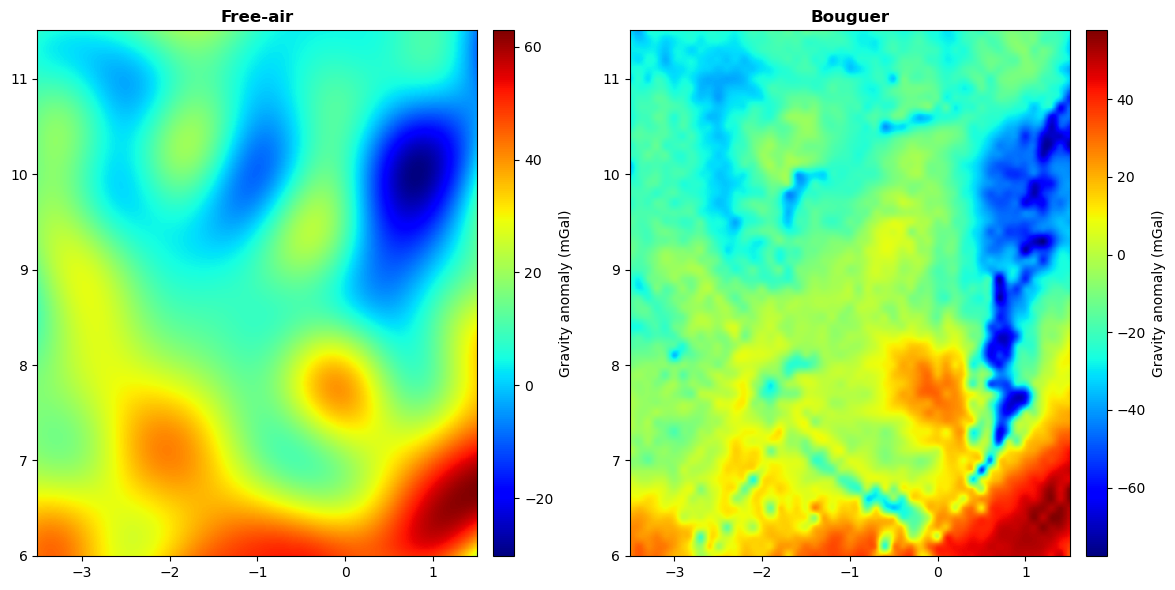

In [43]:
df_anomalies = pd.DataFrame({
    'lon': lon_flat,
    'lat': lat_flat,
    'free_air': free_air_anomaly,
    'bouguer': bouguer_anomaly
})

plot_gravity_anomaly(data=df_anomalies, ellipsoid='grs80')

### Option 2: Manual plotting

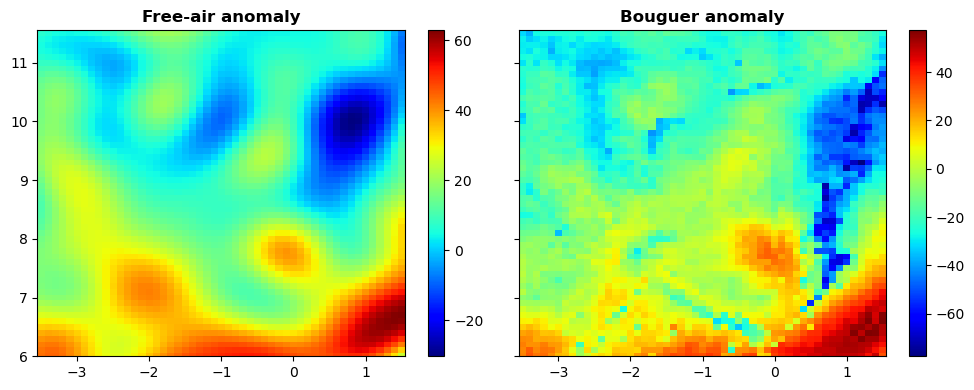

In [47]:
# VMIN, VMAX = -60, 60

VMIN, VMAX = None, None


Dg = np.reshape(free_air_anomaly, Lon.shape)
DgB = np.reshape(bouguer_anomaly, Lon.shape)

fig, axs = plt.subplots(1, 2, figsize=[10, 4], sharey=True)
axs = axs.flatten()


im = axs[0].pcolormesh(lon_vals, lat_vals, Dg, cmap='jet', vmin=VMIN, vmax=VMAX)
fig.colorbar(im, ax=axs[0])
axs[0].set_title('Free-air anomaly', fontweight='bold')

im = axs[1].pcolormesh(lon_vals, lat_vals, DgB, cmap='jet', vmin=VMIN, vmax=VMAX)
fig.colorbar(im, ax=axs[1])
axs[1].set_title('Bouguer anomaly', fontweight='bold')

for ax in axs:
    ax.set_ylim(bottom=6)

fig.tight_layout()
plt.show()

### Option 2: Pass raw data and let `plot_gravity_anomaly` compute anomalies internally

**Important:** `plot_gravity_anomaly` calls `gravity_anomalies()` under the hood, which expects **raw surface gravity** $g$ (not already-reduced gravity). It applies the free-air reduction internally. Passing $g_F$ would double-apply the free-air correction.

Calculating gravity anomalies ...
Gravity anomaly computation completed.


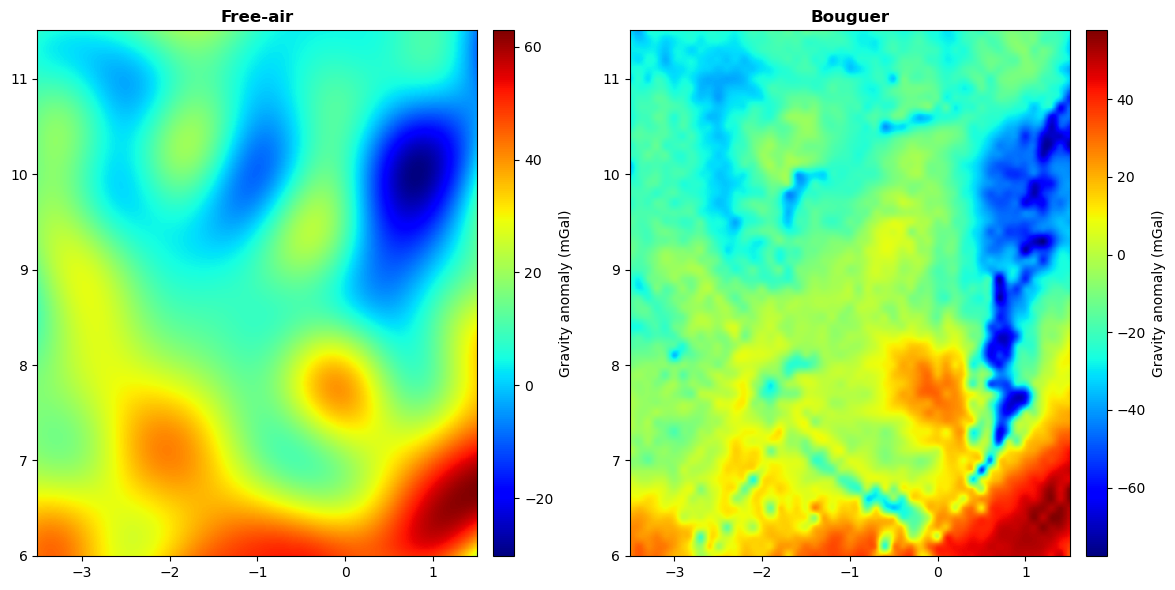

In [49]:
df_raw = pd.DataFrame({
    'lon': lon_flat,
    'lat': lat_flat,
    'gravity': g_surface,
    'height': H
})

plot_gravity_anomaly(gravity_data=df_raw, ellipsoid='grs80')

## 8. Tide System Conversion

Gravity data and physical heights can be expressed in different **permanent tide systems**:

| Tide system | Description |
|-------------|-------------|
| **Mean-tide** | Includes the permanent (time-averaged) tidal potential. Gravity and heights are referenced to the "mean" figure of the Earth, which includes the permanent deformation. |
| **Zero-tide** | The permanent tidal potential is removed. The Earth's crust is assumed to respond elastically, but the permanent tide-generating potential itself is absent. |
| **Tide-free** | Both the permanent tidal potential and the corresponding permanent crustal deformation are removed. This is the system most GGM models use. |

### Why conversion matters

If your observed gravity or heights are in a **different** tide system than the reference model (GGM, DEM, or geoid model) you are comparing against, the mismatch introduces systematic errors—typically on the order of 5–15 cm in height and tens of µGal in gravity. Before computing reductions or anomalies you must **ensure both datasets share the same tide system**.

The GO_CONS_GCF_2_TIM_R6e model (like most modern GGMs) is in the **tide-free** system. Our synthetic surface gravity $g(P)$ inherits this system. If we were working with *observed* gravity data in the mean-tide system (e.g., raw terrestrial measurements), we would need to convert it first.

### How `geoidlab` handles it

`GravityTideSystemConverter` provides two conversion methods:

- **`mean2free()`** — converts mean-tide gravity to tide-free gravity, adjusting both the gravity value and the orthometric height.
- **`free2mean()`** — reverse conversion: tide-free → mean-tide.
- **`zero2free()`** - converts zero-tide gravity to tide-free

The correction uses standard latitude-dependent formulas (Tenzer et al., 2010; Ekman, 1989) with configurable Love numbers $k$, $h$ and the delta factor $d$.

For this demonstration, we will be converting from the TIM_R6e's zero-tide to tide-free.

In [51]:
from geoidlab.tide import GravityTideSystemConverter

# Build a DataFrame in the format GravityTideSystemConverter expects:
# columns: lon, lat, H, gravity
df_tide_demo = pd.DataFrame({
    'lon': lon_flat,
    'lat': lat_flat,
    'H': H,
    'gravity': g_surface
})

# Demonstrate zero2free conversion
converter = GravityTideSystemConverter(data=df_tide_demo)
df_tide_free = converter.zero2free()

# Show the (very small) tidal corrections applied
dg_tidal = df_tide_free['g_free'] - df_tide_demo['gravity']
dh_tidal = df_tide_free['height_free'] - df_tide_demo['H']

print(f'Tidal gravity correction:  {dg_tidal.min():.4f} to {dg_tidal.max():.4f} mGal')
print(f'Tidal height correction:   {dh_tidal.min():.4f} to {dh_tidal.max():.4f} m')
print()
print('Corrected DataFrame head:')
df_tide_free.head()

Tidal gravity correction:  0.0142 to 0.0156 mGal
Tidal height correction:   -0.0287 to -0.0262 m

Corrected DataFrame head:


,lon,lat,H,gravity,g_free,height_free
0,-3.5,6.0,150.25,978085.977912,978085.993496,150.221274
1,-3.4,6.0,104.25,978101.271539,978101.287123,104.221274
2,-3.3,6.0,141.50,978089.747694,978089.763278,141.471274
3,-3.2,6.0,122.00,978094.715160,978094.730744,121.971274
4,-3.1,6.0,148.25,978084.610748,978084.626332,148.221274


## 9. Summary

| Step | Description | Key function(s) |
|------|-------------|----------------|
| 1 | Define computation points | `np.meshgrid` |
| 2 | Extract elevations from DEM | `geoidlab.dem.dem4geoid` |
| 3 | Synthesise surface gravity from GGM | `GlobalGeopotentialModel.gravity_disturbance`, `normal_gravity_above_ellipsoid` |
| 4 | Apply free-air & Bouguer reductions | `geoidlab.gravity.gravity_reduction` |
| 5 | Compute normal gravity on ellipsoid | `geoidlab.gravity.normal_gravity_somigliana` |
| 6 | Compute anomalies: $\Delta g = g_\text{reduced} - \gamma_0$ | manual / `geoidlab.gravity.gravity_anomalies` |
| 7 | Plot | `geoidlab.plot.plot_gravity_anomaly` |

This tutorial demonstrates that gravity reductions and anomalies can be computed entirely without observed gravity data. Given a GGM and a DEM, the full pipeline\u2014from surface gravity synthesis to anomaly mapping\u2014is self-contained.